In [1]:
!pip install fil_finder
!pip uninstall -y aplpy 
!pip uninstall -y astropy  
!pip install astropy==5.3.4 
!pip install aplpy 

Defaulting to user installation because normal site-packages is not writeable
Found existing installation: APLpy 2.2.0
Uninstalling APLpy-2.2.0:
  Successfully uninstalled APLpy-2.2.0
Found existing installation: astropy 5.3.4
Uninstalling astropy-5.3.4:
  Successfully uninstalled astropy-5.3.4
Defaulting to user installation because normal site-packages is not writeable
  Using cached astropy-5.3.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.4 kB)
Using cached astropy-5.3.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.3 MB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Defaulting to user installation because normal site-packages is not writeable
  Using cached APLpy-2.2.0-py3-none-any.whl.metadata (2.0 kB)
Using cached APLpy-2.2.0-py3-none-any.whl (85 kB)


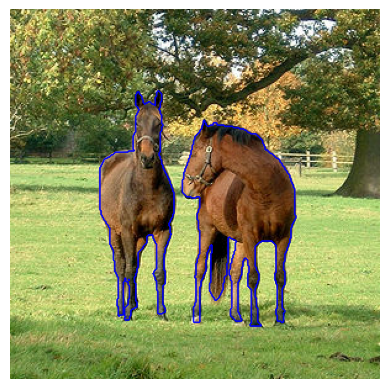

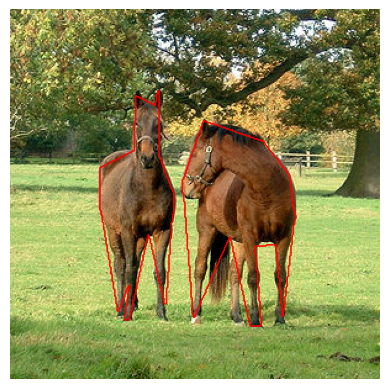

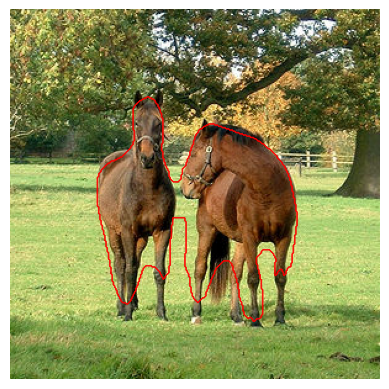

In [2]:
from glob import glob
import os, torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import label, skeletonize

from fil_finder import FilFinder2D
import astropy.units as u


VOC_filename_list = glob('../../VOC2012_source/perfe/*/*.png')

selected_perf_msk_path = '../../VOC2012_source/perfe/SegmentationClass/2008_002338.png'
selected_img_path = f'../../VOC2012_source/JPEGImages/{selected_perf_msk_path.split("/")[-1][:-3]}jpg'
img = np.array(Image.open(selected_img_path).convert('RGB'))

msk_perf = torch.from_numpy(np.array(Image.open(selected_perf_msk_path)))
msk_perf[msk_perf==255]=0

msk_poly = torch.from_numpy(np.array(Image.open(selected_perf_msk_path.replace('/perfe/','/poly-/'))))
msk_poly[msk_poly==255]=0

msk_rough = torch.from_numpy(np.array(Image.open('../../semseg/dataset/voc2012/rough90/SegmentationClass/2008_002338.png')))
msk_rough[msk_rough==255]=0

plt.imshow(img[50:350,100:400])
plt.contour(msk_perf[50:350,100:400],colors='blue', linewidths=.25)
plt.axis('off')
plt.show()

plt.imshow(img[50:350,100:400])
plt.contour(msk_poly[50:350,100:400],colors='red', linewidths=.25)
plt.axis('off')
plt.show()

plt.imshow(img[50:350,100:400])
plt.contour(msk_rough[50:350,100:400],colors='red', linewidths=.25)
plt.axis('off')
plt.show()




/home/yz696/.local/lib/python3.11/site-packages/fil_finder/filfinder2D.py:142: UserWarning: No beam width given. Using 0 pixels.
  warnings.warn("No beam width given. Using 0 pixels.")
/home/yz696/.local/lib/python3.11/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/yz696/.local/lib/python3.11/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/yz696/.local/lib/python3.11/site-packages/fil_finder/filfinder2D.py:296: UserWarning: Using inputted mask. Skipping creation of anew mask.
  warnings.warn("Using inputted mask. Skipping creation of a"
/home/yz696/.local/lib/python3.11/site-packages/fil_finder/filament.py:326: UserWarning: Graph pruning reached max iterations.
  warnings.warn("Graph pruning reached max iterations.")


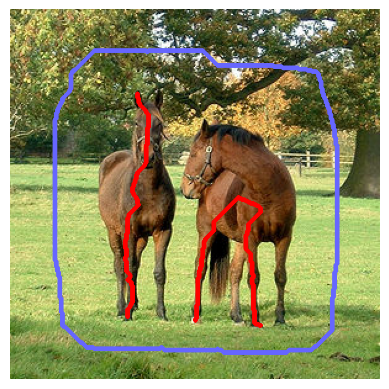

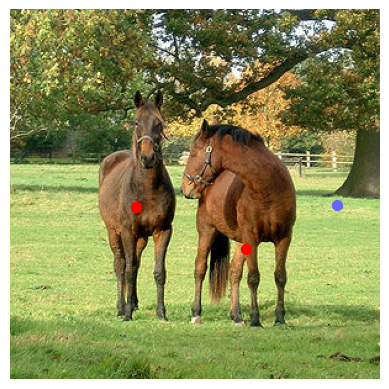

In [3]:
from skimage.morphology import dilation, erosion,disk
from sklearn.cluster import KMeans
pos_point_coords = []
neg_point_coords = []

plt.imshow(img[50:350,100:400])
scrib_msk = np.zeros_like(msk_perf[50:350,100:400])

skeleton = skeletonize(msk_perf[50:350,100:400].numpy()).astype('uint8')

fil = FilFinder2D(skeleton, distance= u.pc, mask=skeleton)
fil.preprocess_image(flatten_percent=50)
fil.create_mask(border_masking=True, verbose=False, use_existing_mask=True)
fil.medskel(verbose=False)
fil.analyze_skeletons(branch_thresh=10* u.pix, skel_thresh=10 * u.pix, prune_criteria='length')
# plt.imshow(fil.skeleton, cmap='gray')
plt.contour(fil.skeleton_longpath, colors='r')
plt.axis('off')

labelled_skeleton, max_id = label(fil.skeleton_longpath, return_num=True)
for component_id in range(1,max_id+1):
    scrib_coords = np.argwhere(labelled_skeleton == component_id)
    centroid = np.mean(scrib_coords, axis=0)
    arg_min_squared_distance = np.argmin(np.sum((scrib_coords - centroid)**2,axis=1))
    pos_point_coords.append(scrib_coords[arg_min_squared_distance])


skeleton = skeletonize(msk_perf[50:350,100:400].numpy() == 0).astype('uint8')
temp = np.argwhere(skeleton>0)
np.random.shuffle(temp)
for i in range(2):
    _coord = temp[i]
    skeleton[_coord[0]:_coord[0]+1, _coord[1]:_coord[1]+1]=0
    
fil = FilFinder2D(skeleton, distance= u.pc, mask=skeleton)
fil.preprocess_image(flatten_percent=50)
fil.create_mask(border_masking=True, verbose=False, use_existing_mask=True)
fil.medskel(verbose=False)
fil.analyze_skeletons(branch_thresh=10* u.pix, skel_thresh=10 * u.pix, prune_criteria='length')
# plt.imshow(fil.skeleton, cmap='gray')
plt.contour(fil.skeleton_longpath, colors='#6666ff')
plt.axis('off')
plt.show()
scrib_coords = np.argwhere(fil.skeleton_longpath>0)
centroid = np.mean(scrib_coords, axis=0)
arg_min_squared_distance = np.argmin(np.sum((scrib_coords - centroid)**2,axis=1))
neg_point_coords.append(scrib_coords[arg_min_squared_distance])

pos_point_coords = np.array(pos_point_coords)
neg_point_coords = np.array(neg_point_coords)
plt.imshow(img[50:350,100:400])
plt.scatter(pos_point_coords[:,1],pos_point_coords[:,0],c='r',s=50)
plt.scatter(neg_point_coords[:,1],neg_point_coords[:,0],c='#6666ff',s=50)
plt.axis('off')
plt.show()


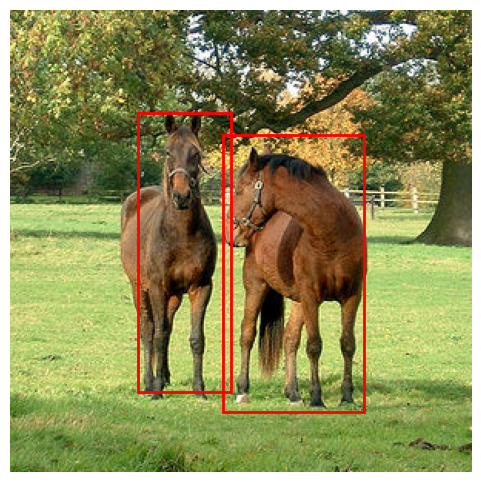

In [4]:
import matplotlib.patches as patches
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img[50:350,100:400])
labelled = label(msk_perf[50:350,100:400])
for component_id in range(1,max_id+1):
    pos_coords = np.argwhere(labelled == component_id)
    y0,x0 = pos_coords.min(axis=0)
    y1,x1 = pos_coords.max(axis=0)
    h,w = x1-x0+1, y1-y0+1
    deviation = (np.random.rand(4)*2-1)*.1*np.array([h,w,h,w])
    y0,x0,y1,x1 = (np.array([y0,x0,y1,x1])+deviation.clip(min=-10,max=10)).clip(min=0,max=300-1)
    rect = patches.Rectangle((x0, y0), x1-x0+1, y1-y0+1, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
ax.axis('off')
plt.show()


    
    